# Week 1 Day 1 — First Molecule

Goal: Load, inspect, and visualize your first molecule with RDKit.

Valid molecule: True
Num atoms: 13
Num bonds: 13
Molecular weight: 180.16


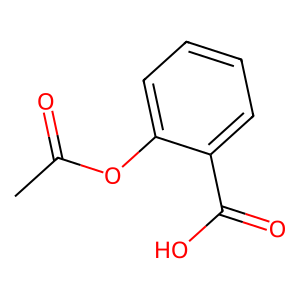

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

# Aspirin
smiles = 'CC(=O)Oc1ccccc1C(=O)O'
mol = Chem.MolFromSmiles(smiles)

print('Valid molecule:', mol is not None)
print('Num atoms:', mol.GetNumAtoms())
print('Num bonds:', mol.GetNumBonds())
print('Molecular weight:', round(Descriptors.MolWt(mol), 2))

Draw.MolToImage(mol, size=(300, 300))

In [2]:
# Load multiple molecules
molecules = {
    'Aspirin':    'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':   'Cn1cnc2c1c(=O)n(c(=O)n2C)C',
    'Ibuprofen':  'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
    'Imatinib':   'Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C',
    'Invalid':    'NOTASMILES'
}

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f'{name}: INVALID SMILES')
    else:
        print(f'{name}: {mol.GetNumAtoms()} atoms, MW={round(Descriptors.MolWt(mol), 2)}')

Aspirin: 13 atoms, MW=180.16
Caffeine: 14 atoms, MW=194.19
Ibuprofen: 15 atoms, MW=206.28
Imatinib: 37 atoms, MW=493.62
Invalid: INVALID SMILES


[05:35:43] SMILES Parse Error: syntax error while parsing: NOTASMILES
[05:35:43] SMILES Parse Error: check for mistakes around position 3:
[05:35:43] NOTASMILES
[05:35:43] ~~^
[05:35:43] SMILES Parse Error: Failed parsing SMILES 'NOTASMILES' for input: 'NOTASMILES'


[05:36:57] SMILES Parse Error: syntax error while parsing: NOTASMILES
[05:36:57] SMILES Parse Error: check for mistakes around position 3:
[05:36:57] NOTASMILES
[05:36:57] ~~^
[05:36:57] SMILES Parse Error: Failed parsing SMILES 'NOTASMILES' for input: 'NOTASMILES'


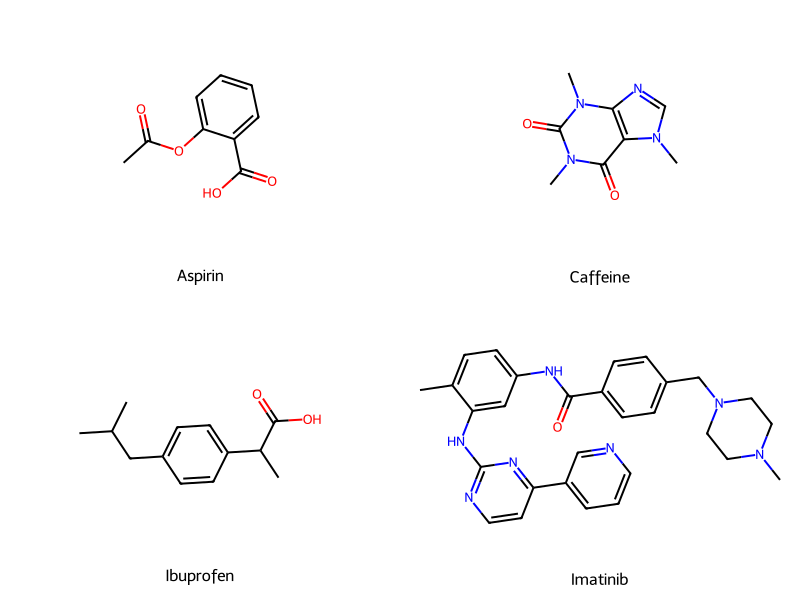

In [3]:
# Visualize all valid molecules in a grid
valid_mols = []
valid_names = []

for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_mols.append(mol)
        valid_names.append(name)

Draw.MolsToGridImage(valid_mols, molsPerRow=2, subImgSize=(400, 300), legends=valid_names)

In [6]:
from rdkit import Chem
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')
print(mol)

In [8]:
print(type(mol))
print(mol.GetNumAtoms())                                                                                                            
print(mol.GetNumBonds())

<class 'rdkit.Chem.rdchem.Mol'>
13
13


In [9]:
for atom in mol.GetAtoms():                                                                                                         
      print(atom.GetIdx(), atom.GetSymbol()) 

0 C
1 C
2 O
3 O
4 C
5 C
6 C
7 C
8 C
9 C
10 C
11 O
12 O


In [10]:
 for atom in mol.GetAtoms():                                                                                                         
      print(                                                
          atom.GetIdx(),                                                                                                              
          atom.GetSymbol(),
          atom.GetIsAromatic(),                                                                                                       
          atom.GetDegree()                                  
      )



0 C False 1
1 C False 3
2 O False 1
3 O False 2
4 C True 3
5 C True 2
6 C True 2
7 C True 2
8 C True 2
9 C True 3
10 C False 3
11 O False 1
12 O False 1


In [11]:
for bond in mol.GetBonds():                                                                                                         
      print(                      
        
          bond.GetBeginAtom().GetSymbol(),
          bond.GetEndAtom().GetSymbol(),
          bond.GetBondTypeAsDouble(),
          bond.IsInRing()                                                                                                             
      )


C C 1.0 False
C O 2.0 False
C O 1.0 False
O C 1.0 False
C C 1.5 True
C C 1.5 True
C C 1.5 True
C C 1.5 True
C C 1.5 True
C C 1.0 False
C O 2.0 False
C O 1.0 False
C C 1.5 True


In [14]:
import pandas as pd                                                                                                                 
                                                            
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"                                   
df = pd.read_csv(url)
                                                                                                                                      
print(df.shape)                                           
print(df.columns.tolist())
df.head()

(1128, 10)
['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [15]:
from rdkit import Chem

valid = 0                                                                                                                           
invalid = 0
                                                                                                                                      
for smi in df['smiles']:                                  
      mol = Chem.MolFromSmiles(smi)
      if mol is None:
          invalid += 1
      else:
          valid += 1

  print(f"Valid:   {valid}")                                                                                                          
  print(f"Invalid: {invalid}")

IndentationError: unexpected indent (3274903114.py, line 3)